<a href="https://colab.research.google.com/github/Brunolms11/Calc_Numerico/blob/main/Atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3 - Parte A

In [1]:
#Importando as bibliotecas e definindo os valores

import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
valores_x = {"x1": 3.14159265, "x2":98.76543, "x3" : 0.00498765}
resultados = []

In [2]:
#Definindo a funcao de truncamento usando a definicao do enunciado
def trunc (x,n):
  return (math.trunc((10**n)*x))/(10**n)


In [3]:
for nome,valor in valores_x.items():
  for i in range(5):

    x_trunc = trunc(valor,i)
    x_rounded = round(valor,i)
    #Calculos dos erros para Truncamento
    Ea_trunc = abs(valor - x_trunc)
    Er_trunc = Ea_trunc / abs(valor)
    Ep_trunc = Er_trunc * 100

    #Calculos dos erros para Arredondamento
    Ea_round = abs(valor - x_rounded)
    Er_round = Ea_round / abs(valor)
    Ep_round = Er_round * 100

    resultados.append( {
                "Variável": nome,
                "n": i,
                "x": valor,
                "Truncado": x_trunc,
                "Ea (Trunc)": Ea_trunc,
                "Er (Trunc)": Er_trunc,
                "E% (Trunc)": Ep_trunc,
                "Arredondado": x_rounded,
                "Ea (Arred)": Ea_round,
                "Er (Arred)": Er_round,
                "E% (Arred)": Ep_round,
            }
        )
#Exibicao e Organizacao dos resultados
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

Variável  n         x  Truncado  Ea (Trunc)   Er (Trunc)  E% (Trunc)  Arredondado  Ea (Arred)   Er (Arred)  E% (Arred)
      x1  0  3.141593    3.0000    0.141593 4.507034e-02    4.507034       3.0000    0.141593 4.507034e-02    4.507034
      x1  1  3.141593    3.1000    0.041593 1.323935e-02    1.323935       3.1000    0.041593 1.323935e-02    1.323935
      x1  2  3.141593    3.1400    0.001593 5.069562e-04    0.050696       3.1400    0.001593 5.069562e-04    0.050696
      x1  3  3.141593    3.1410    0.000593 1.886464e-04    0.018865       3.1420    0.000407 1.296635e-04    0.012966
      x1  4  3.141593    3.1415    0.000093 2.949141e-05    0.002949       3.1416    0.000007 2.339578e-06    0.000234
      x2  0 98.765430   98.0000    0.765430 7.749979e-03    0.774998      99.0000    0.234570 2.375021e-03    0.237502
      x2  1 98.765430   98.7000    0.065430 6.624788e-04    0.066248      98.8000    0.034570 3.500213e-04    0.035002
      x2  2 98.765430   98.7600    0.005430 5.49

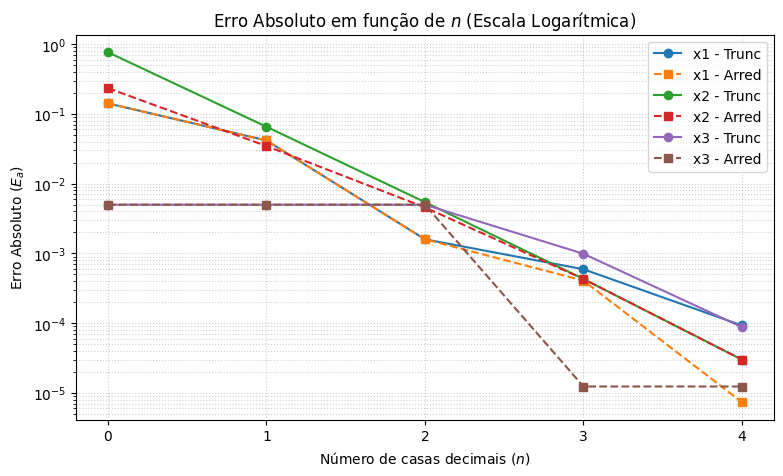

In [4]:
# Criar a figura
plt.figure(figsize=(9, 5))
n_valores = [0,1,2,3,4]
for nome, x in valores_x.items():
    Ea_trunc = [abs(x - trunc(x, n)) for n in range(5)]
    Ea_arred = [abs(x - round(x, n)) for n in range(5)]

    # Plota a linha de truncamento (contínua) e de arredondamento (tracejada)
    plt.plot(n_valores, Ea_trunc, marker="o", label=f"{nome} - Trunc")
    plt.plot(
        n_valores, Ea_arred, marker="s", linestyle="--", label=f"{nome} - Arred"
    )

# Escala logarítmica no eixo Y
plt.yscale("log")

# Formatação do gráfico
plt.xlabel("Número de casas decimais ($n$)")
plt.ylabel("Erro Absoluto ($E_a$)")
plt.title("Erro Absoluto em função de $n$ (Escala Logarítmica)")
plt.xticks(n_valores)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()

Parte A.
5 - Arredondar sempre gera um erro menor ou igual do que ao fazer por truncamento, como evidenciado nos resultados, pois nao houve nenhum tipo de erro em nenhum valor truncado que obteve um resultado menor do que ao usar dados arredondados

# 4 - PARTE B

B.1

In [5]:

#Definindo as Series para calcular os valores estatisticos em seguida

dados_originais = [121.7,120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
print(dados_originais)
#Criando listas para armazenar os valores
dados_arredondandos =[]
dados_trunc =[]
#calculando dados arredondados
for d in dados_originais:
  dados_arredondandos.append(round(d))
print(dados_arredondandos)
#calculando dados truncados para inteiros
for d in dados_originais:
  dados_trunc.append(trunc(d,0))
print(dados_trunc)


[121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
[122, 120, 122, 120, 121, 121, 122, 121, 120, 122]
[121.0, 120.0, 122.0, 119.0, 121.0, 120.0, 122.0, 121.0, 120.0, 121.0]


In [6]:
#---Estatisticas dados originais---
estat_dados_originais ={}
media_o = np.mean(dados_originais)
#como a media de referencia deve ser a calculada usando todos os algarismos disponiveis
#ela coincidira com a media dos dados originais
print(f"Referencia de Media:",media_o)
minimo_o = np.min(dados_originais)
maximo_o = np.max(dados_originais)
amplitude_o = np.ptp(dados_originais)
dp_o = np.std(dados_originais)
estat_dados_originais.update({"Media":media_o,"Minimo":minimo_o,"Maximo":maximo_o,"Amplitude":amplitude_o,"Desvio Padrao":dp_o})

print("\n --Estatisticas para os dados originais-- ")
for key, value in enumerate(estat_dados_originais):
  str_array = [f"{estat_dados_originais[value]:.2f}"]
  print(f"{value}={' '.join(str_array)}")

#print(f"Estatisticas para os dados originais: \n",estat_dados_originais)

#---Estatisticas para os dados arredondados---
estat_dados_arredondados = {}
media_r = np.mean(dados_arredondandos)
minimo_r = np.min(dados_arredondandos)
maximo_r = np.max(dados_arredondandos)
amplitude_r = np.ptp(dados_arredondandos)
dp_r = np.std(dados_arredondandos)
estat_dados_arredondados.update({"Media":media_r,"Minimo":minimo_r,"Maximo":maximo_r,"Amplitude":amplitude_r,"Desvio Padrao":dp_r})
print("\n --Estatisticas para os dados arredondados--")
for key, value in enumerate(estat_dados_arredondados):
  str_array = [f"{estat_dados_arredondados[value]:.2f}"]
  print(f"{value}={' '.join(str_array)}")

#---Estatisticas para os dados truncados---
estat_dados_trunc = {}
media_t = np.mean(dados_trunc)
minimo_t = np.min(dados_trunc)
maximo_t = np.max(dados_trunc)
amplitude_t = np.ptp(dados_trunc)
dp_t = np.std(dados_trunc)
estat_dados_trunc.update({"Media":media_t,"Minimo":minimo_t,"Maximo":maximo_t,"Amplitude":amplitude_t,"Desvio Padrao":dp_t})
#print(f"Estatisticas para os dados truncados: \n",estat_dados_trunc)
print("\n --Estatisticas para os dados truncados--")
for key, value in enumerate(estat_dados_trunc):
  str_array = [f"{estat_dados_trunc[value]:.4f}"]
  print(f"{value}={' '.join(str_array)}")

#---calculos dos erros das medias---


xref = media_o
Ea_arred_media= abs(xref- media_r)
Er_arred_media = Ea_arred_media / abs(xref)
Ep_arred_media = Er_arred_media * 100
erros_media_r = {"Ea_dados_arredondados":Ea_arred_media,"Er_dados_arredondados":Er_arred_media,"Ep_dados_arredondados":Ep_arred_media}
#print(f"Erros para os dados arredondados: \n",erros_media_r)
print("\n --Erros (media) para os dados arredondados--")
for key, value in enumerate(erros_media_r):
  str_array = [f"{erros_media_r[value]:.4f}"]
  print(f"{value}={' '.join(str_array)}")

Ea_trunc_media= abs(xref- media_t)
Er_trunc_media = Ea_trunc_media / abs(xref)
Ep_trunc_media = Er_trunc_media * 100
erros_media_t = {"Ea_dados_truncados":Ea_trunc_media,"Er_dados_truncados":Er_trunc_media,"Ep_dados_truncados":Ep_trunc_media}
#print(f"Erros para os dados truncados: \n",erros_media_t)
print("\n --Erros (media) para os dados truncados--")
for key, value in enumerate(erros_media_t):
  str_array = [f"{erros_media_t[value]:.4f}"]
  print(f"{value}={' '.join(str_array)}")


Referencia de Media: 121.12

 --Estatisticas para os dados originais-- 
Media=121.12
Minimo=119.80
Maximo=122.40
Amplitude=2.60
Desvio Padrao=0.79

 --Estatisticas para os dados arredondados--
Media=121.10
Minimo=120.00
Maximo=122.00
Amplitude=2.00
Desvio Padrao=0.83

 --Estatisticas para os dados truncados--
Media=120.7000
Minimo=119.0000
Maximo=122.0000
Amplitude=3.0000
Desvio Padrao=0.9000

 --Erros (media) para os dados arredondados--
Ea_dados_arredondados=0.0200
Er_dados_arredondados=0.0002
Ep_dados_arredondados=0.0165

 --Erros (media) para os dados truncados--
Ea_dados_truncados=0.4200
Er_dados_truncados=0.0035
Ep_dados_truncados=0.3468


B.2


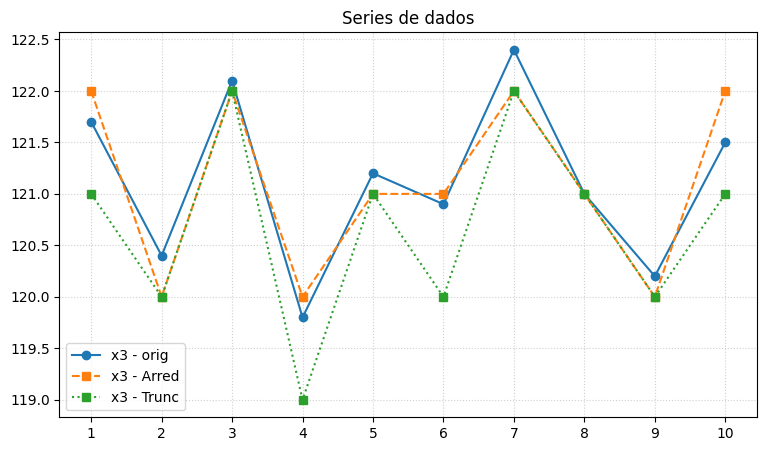

In [7]:
#Graficos

plt.figure(figsize=(9, 5))
x_axis= [1,2,3,4,5,6,7,8,9,10]
#for nome, x in valores_x.items():
#   Ea_trunc = [abs(x - trunc(x, n)) for n in range(5)]
#    Ea_arred = [abs(x - round(x, n)) for n in range(5)]

# Plota a linha de truncamento (contínua) e de arredondamento (tracejada)
plt.plot(x_axis, dados_originais, marker="o", label=f"{nome} - orig")
plt.plot(
        x_axis, dados_arredondandos,marker="s", linestyle="--", label=f"{nome} - Arred"
)
plt.plot(
        x_axis, dados_trunc,marker="s", linestyle=":", label=f"{nome} - Trunc"
)
plt.title("Series de dados")
plt.xticks(x_axis)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()


/tmp/ipykernel_2816/877388724.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


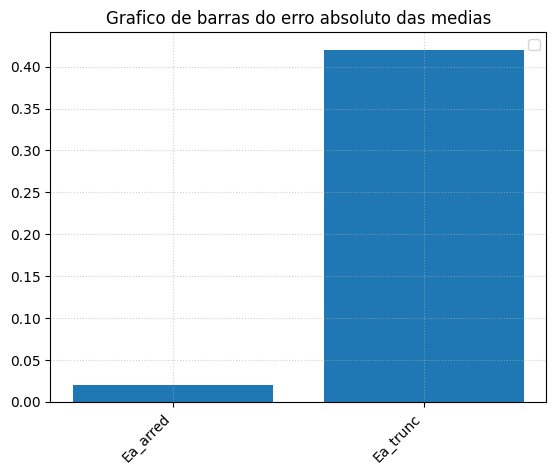

In [8]:
#Codigo de barras dos erros absolutos
x_axis=[1,2]
#Criando uma lista para armazenar os 6 valores de erros em relacao a media
erro_absoluto_das_medias = [Ea_arred_media,Ea_trunc_media]
#Plot do grafico de barras
plt.bar(x_axis,erro_absoluto_das_medias)
plt.title("Grafico de barras do erro absoluto das medias")

#Criando lista com os nomes das barras
nomes_barras = ['Ea_arred', 'Ea_trunc']
plt.xticks(x_axis, nomes_barras, rotation=45, ha='right')
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()

/tmp/ipykernel_2816/2444019476.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


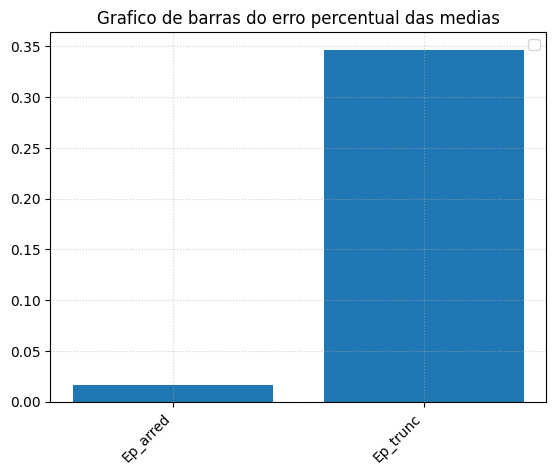

In [9]:
#Codigo de barras dos erros percentuais
x_axis=[1,2]
#Criando uma lista para armazenar os 6 valores de erros em relacao a media
erro_percentuais_das_medias = [Ep_arred_media,Ep_trunc_media]
#Plot do grafico de barras
plt.bar(x_axis,erro_percentuais_das_medias)
plt.title("Grafico de barras do erro percentual das medias")

#Crinado ista com os nomes das barras
nomes_barras = ['Ep_arred', 'Ep_trunc']
plt.xticks(x_axis, nomes_barras, rotation=45, ha='right')
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()

/tmp/ipykernel_2816/1915089118.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


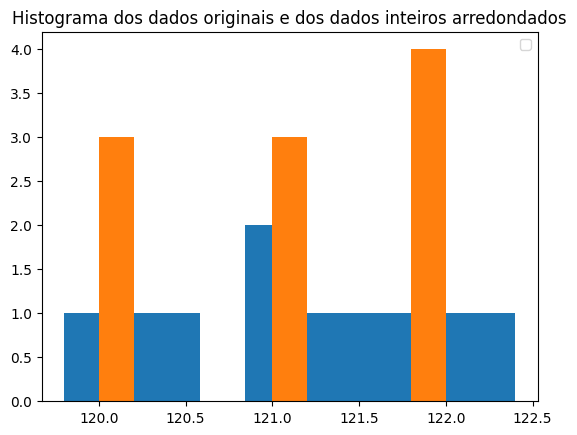

In [10]:
#Histograma dos dados originais e dos dados inteiros arredondados

plt.hist(dados_originais)
plt.hist(dados_arredondandos)

plt.title("Histograma dos dados originais e dos dados inteiros arredondados")
nomes_hist = ['Dados originais', 'Dados arredondados']

plt.legend()
plt.show()


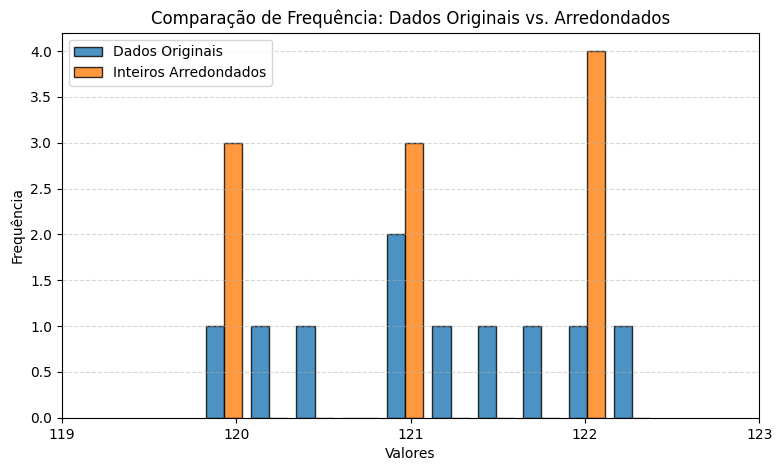

In [11]:
#HISTOGRAMA dos dados originais e dos dados inteiros arredondados.

#definindo os limites exatos das barras para alinhar aos números inteiros
#bins = np.arange(119, 124) - 0.5

#criando o gráfico
plt.figure(figsize=(9, 5))

plt.hist(
    [dados_originais, dados_arredondandos],
    #bins=bins,
    label=["Dados Originais", "Inteiros Arredondados"],
    edgecolor="black",
    alpha=0.8,
)

# Customização do Gráfico
plt.title("Comparação de Frequência: Dados Originais vs. Arredondados")
plt.xlabel("Valores")
plt.ylabel("Frequência")
plt.xticks(range(119, 124))  # Exibe no eixo X apenas os números inteiros
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.show()

A representação inteira claramente se mostrou insuficiente, principalmente em relação a variabilidade da amostra, pois como podemos ver no histograma, os dados arredondados para o inteiro mais proximo apresenta apenas 3 valores diferentes (120,121 e 122), enquanto os dados originais demonstram muito menos homogeneidade.

# 5 - Parte C

In [12]:
# q = [np.pi*r^4*Delta(p)]/8*mu*L
r = 0.80 #mm
L = 0.20 #m
mu = 3.5 / 1000 #Pa
delta_p = 1200 #Pa

q = (np.pi*(r**4)*delta_p)/8*mu*L
print(f"Q com valores fornecidos: {q}")

#calculos de r
r2 = round(r, 1)
r3 = trunc(r, 1)

q1 = (np.pi*(r2**4)*delta_p)/8*mu*L
print(f"Q para r arredondado com 1 casa decimal: {q1}")
erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")


q1 = (np.pi*(r3**4)*delta_p)/8*mu*L
print(f"Q para r truncado com 1 casa decimal: {q1}")
erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

#calculos de mu
mu2 = round(mu, 3)
mu3 = trunc(mu, 3)

q1 = (np.pi*(r**4)*delta_p)/8*mu2*L
print(f"Q para mu arredondado com 3 casas decimais: {q1:.4f}")
erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")


q1 = (np.pi*(r**4)*delta_p)/8*mu3*L
print(f"Q para mu truncado com 3 casas decimais: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

#calculos de Delta_p -> mostrar em kPa
delta_p2 = round(delta_p/1000, 2) #usando kPa como recomendado
delta_p3 = trunc(delta_p/1000, 2) #usando kPa como recomendado

q1 = (np.pi*(r**4)*delta_p2)/8*mu*L
print(f"Q para delta_p arredondado com 2 casas decimais: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

q1 = (np.pi*(r**4)*delta_p3)/8*mu*L
print(f"Q para delta_p truncado com 2 casas decimais: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

q1 = (np.pi*(r2**4)*delta_p2)/8*mu2*L
print(f"Q para todas as medidas arredondas com os respectivos requisitos: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

q1 = (np.pi*(r3**4)*delta_p3)/8*mu3*L
print(f"Q para todas as medidas truncadas com os respectivos requisitos: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

Q com valores fornecidos: 0.13511361684558987
Q para r arredondado com 1 casa decimal: 0.13511361684558987
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0
Q para r truncado com 1 casa decimal: 0.13511361684558987
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0
Q para mu arredondado com 3 casas decimais: 0.1544
Erro absoluto = 0.019301945263655695
Erro relativo = 0.14285714285714285
Erro percentual = 14.285714285714285
Q para mu truncado com 3 casas decimais: 0.11581167158193417
Erro absoluto = 0.019301945263655695
Erro relativo = 0.14285714285714285
Erro percentual = 14.285714285714285
Q para delta_p arredondado com 2 casas decimais: 0.00013511361684558984
Erro absoluto = 0.13497850322874427
Erro relativo = 0.999
Erro percentual = 99.9
Q para delta_p truncado com 2 casas decimais: 0.00013511361684558984
Erro absoluto = 0.13497850322874427
Erro relativo = 0.999
Erro percentual = 99.9
Q para todas as medidas arredondas com os respectivos requisitos: 0.00015441

# 6 Parte - D

In [13]:
#colocando os parametros no SI
r_nominal = 50e-9  #50nm
L = 10e-6  #10 micro m
mu = 3.5e-3  #Pas
delta_p = 5000  #Pa

def calcular_Q(r):
    return (np.pi * (r**4) * delta_p) / (8 * mu * L)


Q_nominal = calcular_Q(r_nominal)

#criando vetor com as variacoes do erro no raio
delta_r_array = np.arange(0.1e-9, 5.1e-9, 0.1e-9)

#Criando listas para os erros máximos para cada delta_r
erro_abs_max = []
erro_rel_max = []
erro_pct_max = []
aprox_linear = []

#Criando listas para os graficos de Q(r-), Q(r) e Q(r+)
Q_menos_list = []
Q_mais_list = []

for dr in delta_r_array:
    r_menos = r_nominal - dr
    r_mais = r_nominal + dr

    Q_menos = calcular_Q(r_menos)
    Q_mais = calcular_Q(r_mais)

    Q_menos_list.append(Q_menos)
    Q_mais_list.append(Q_mais)

    #Calculando o erro maximo (ocorre no ponto mais distante r+)
    e_abs = abs(Q_mais - Q_nominal)
    e_rel = e_abs / Q_nominal
    e_pct = e_rel * 100

    erro_abs_max.append(e_abs)
    print (f"Erro relativo max {e_rel}")
    erro_rel_max.append(e_rel)
    erro_pct_max.append(e_pct)

    #Aproximação linear da equacao (5)
    aprox_linear.append(4 * (dr / r_nominal))



Erro relativo max 0.008024032015999915
Erro relativo max 0.01609625625600012
Erro relativo max 0.024216865296000086
Erro relativo max 0.032386052095999734
Erro relativo max 0.04060400999999966
Erro relativo max 0.048870932735999704
Erro relativo max 0.057187014415999805
Erro relativo max 0.0655524495360001
Erro relativo max 0.07396743297600006
Erro relativo max 0.08243216000000012
Erro relativo max 0.09094682625600016
Erro relativo max 0.09951162777599987
Erro relativo max 0.1081267609759996
Erro relativo max 0.11679242265599986
Erro relativo max 0.1255088099999997
Erro relativo max 0.1342761205759999
Erro relativo max 0.14309455233600027
Erro relativo max 0.15196430361600013
Erro relativo max 0.16088557313599947
Erro relativo max 0.16985855999999966
Erro relativo max 0.1788834636959999
Erro relativo max 0.18796048409599977
Erro relativo max 0.19708982145599993
Erro relativo max 0.2062716764159999
Erro relativo max 0.21550625000000012
Erro relativo max 0.22479374361599955
Erro relativo

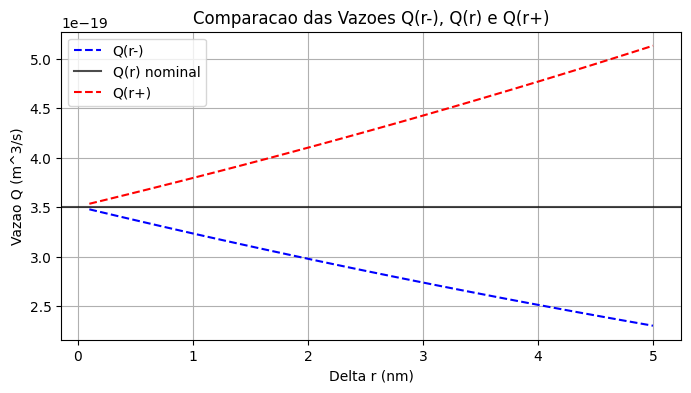

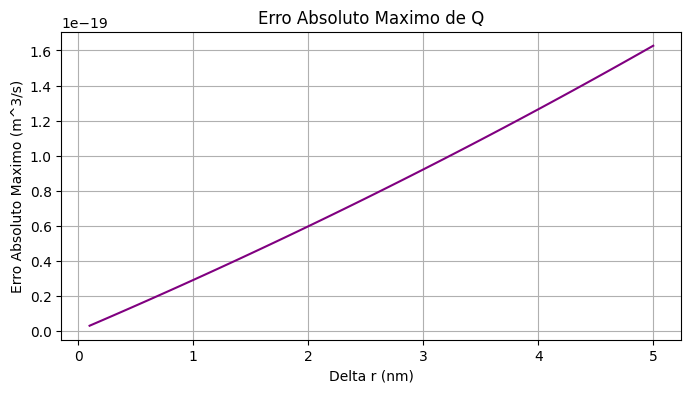

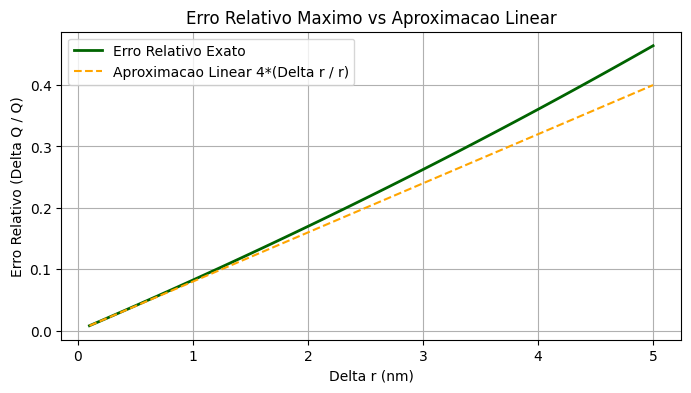

In [14]:
#GRAFICOS
#1 - Grafico de Q(r-), Q(r) e Q(r+)
plt.figure(figsize=(8, 4))
plt.plot(
    delta_r_array * 1e9,
    Q_menos_list,
    label="Q(r-)",
    color="blue",
    linestyle="--",
)
plt.axhline(
    Q_nominal, label="Q(r) nominal", color="black", linestyle="-", alpha=0.7
)
plt.plot(
    delta_r_array * 1e9, Q_mais_list, label="Q(r+)", color="red", linestyle="--"
)
plt.xlabel("Delta r (nm)")
plt.ylabel("Vazao Q (m^3/s)")
plt.title("Comparacao das Vazoes Q(r-), Q(r) e Q(r+)")
plt.legend()
plt.grid(True)
plt.show()

#2 - Erro absoluto maximo
plt.figure(figsize=(8, 4))
plt.plot(delta_r_array * 1e9, erro_abs_max, color="purple")
plt.xlabel("Delta r (nm)")
plt.ylabel("Erro Absoluto Maximo (m^3/s)")
plt.title("Erro Absoluto Maximo de Q")
plt.grid(True)
plt.show()

#3 e 4 - Erro relativo / percentual vs aproximacao linear
plt.figure(figsize=(8, 4))
plt.plot(
    delta_r_array * 1e9,
    erro_rel_max,
    label="Erro Relativo Exato",
    color="darkgreen",
    linewidth=2,
)
plt.plot(
    delta_r_array * 1e9,
    aprox_linear,
    label="Aproximacao Linear 4*(Delta r / r)",
    color="orange",
    linestyle="--",
)
plt.xlabel("Delta r (nm)")
plt.ylabel("Erro Relativo (Delta Q / Q)")
plt.title("Erro Relativo Maximo vs Aproximacao Linear")
plt.legend()
plt.grid(True)
plt.show()

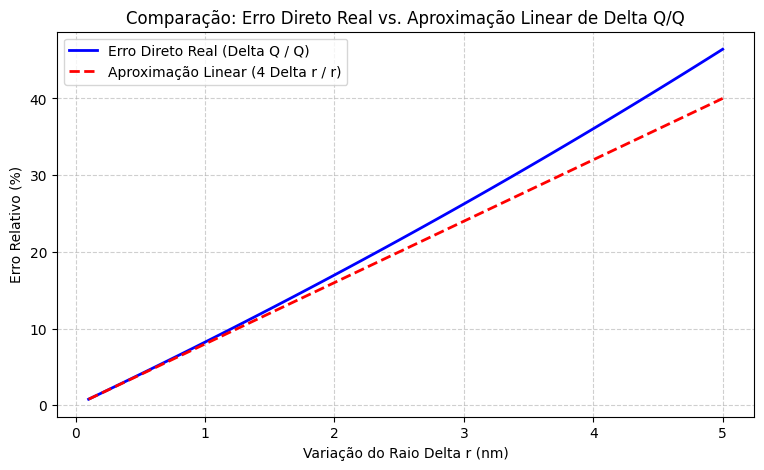

Para Delta r = 0.1 nm:
  - Erro Direto Real:     0.8024%
  - Aproximação Linear:   0.8000%
  - Diferença Absoluta:   0.0024%

Para Delta r = 5.0 nm:
  - Erro Direto Real:     46.4100%
  - Aproximação Linear:   40.0000%
  - Diferença Absoluta:   6.4100%


In [15]:
#Comparação do erro direto com a aproximação linear
#Calculando a diferença absoluta e o erro relativo percentual entre os dois métodos
diferenca_absoluta = np.abs(np.array(erro_rel_max) - np.array(aprox_linear))

#Criando o gráfico comparativo
plt.figure(figsize=(9, 5))

plt.plot(
    delta_r_array * 1e9,
    np.array(erro_rel_max) * 100,
    label="Erro Direto Real (Delta Q / Q)",
    color="blue",
    linewidth=2,
)
plt.plot(
    delta_r_array * 1e9,
    np.array(aprox_linear) * 100,
    label="Aproximação Linear (4 Delta r / r)",
    color="red",
    linestyle="--",
    linewidth=2,
)
plt.title("Comparação: Erro Direto Real vs. Aproximação Linear de Delta Q/Q")
plt.xlabel("Variação do Raio Delta r (nm)")
plt.ylabel("Erro Relativo (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

#Exibição numérica dos pontos extremos para justificativa
print(
    f"Para Delta r = {delta_r_array[0]*1e9:.1f} nm:"
)
print(f"  - Erro Direto Real:     {erro_rel_max[0]*100:.4f}%")
print(f"  - Aproximação Linear:   {aprox_linear[0]*100:.4f}%")
print(f"  - Diferença Absoluta:   {diferenca_absoluta[0]*100:.4f}%\n")

print(
    f"Para Delta r = {delta_r_array[-1]*1e9:.1f} nm:"
)
print(f"  - Erro Direto Real:     {erro_rel_max[-1]*100:.4f}%")
print(f"  - Aproximação Linear:   {aprox_linear[-1]*100:.4f}%")
print(f"  - Diferença Absoluta:   {diferenca_absoluta[-1]*100:.4f}%")

Ou seja, a medida que o erro direto cresce a aproximacao linear deixa de "acompanhar", fazendo com que os valores se diferenciem cada vez mais. Entretanto, nos valores iniciais da serie, as duas medidas sao bem semelhantes.

In [16]:
#Iniciando os calculos das variacoes e erros para float32 e float64
resultados_np = []

#Funcao para calcular o Q usando np32
def calcular_Q_np32(r):
    r_32 = np.float32(r)
    dp_32 = np.float32(delta_p)
    mu_32 = np.float32(mu)
    L_32 = np.float32(L)
    pi_32 = np.float32(np.pi)
    return (pi_32 * (r_32**4) * dp_32) / (np.float32(8) * mu_32 * L_32)

#Funcao para calcular o Q usando np64
def calcular_Q_np64(r):
    r_64 = np.float64(r)
    dp_64 = np.float64(delta_p)
    mu_64 = np.float64(mu)
    L_64 = np.float64(L)
    pi_64 = np.float64(np.pi)
    return (pi_64 * (r_64**4) * dp_64) / (np.float64(8) * mu_64 * L_64)

#reutilizando a variavel r_nominal do exercicio anterior
Q_np32= calcular_Q_np32(r_nominal)
r_np32 = (np.float32(r_nominal))
r4_np32 = (np.float32(r_nominal))**4




Q_np64= calcular_Q_np64(r_nominal) #reutilizando a variavel r_nominal do exercicio anterior
r_np64 = (np.float64(r_nominal))
r4_np64 = (np.float64(r_nominal))**4


#Erros dos valores
Ea_r4 = abs(r4_np64 - r4_np32)
Er_r4 = Ea_r4 / abs(r4_np64)

Ea_Q = abs(Q_np64 - Q_np32)
Er_Q = Ea_Q / abs(Q_np64)

#np.finfo(...).eps de cada tipo.
eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

#Variação de vazão para float32
dr_32 = np.float32(dr)
Q_r_dr_32 = calcular_Q_np32(r_nominal + dr_32)
delta1_32 = (Q_r_dr_32 - Q_np32) / Q_np32
delta2_32 = ((np.float32(1) + (dr_32 / r_np32))**4) - np.float32(1)

#Variação de vazão parafloat64
dr_64 = np.float64(dr)
Q_r_dr_64 = calcular_Q_np64(r_nominal + dr_64)
delta1_64 = (Q_r_dr_64 - Q_np64) / Q_np64
delta2_64 = ((np.float64(1) + (dr_64 / r_np64))**4) - np.float64(1)

print("D.2 Precisão Computacional \n")
print(f"r^4:\n(float32): {r4_np32:.8e}\n(float64): {r4_np64:.16e}\n")
print(f"Q:\n(float32): {Q_np32:.8e}\n(float64): {Q_np64:.16e}\n")
print(f"Diferença Absoluta em Q: {Ea_Q:.8e}")
print(f"Diferença Relativa em Q: {Er_Q:.8e}")
print(f"np.finfo(float32).eps:  {eps_32:.8e}")
print(f"np.finfo(float64).eps:  {eps_64:.16e}\n")

print("Variação de Vazão ")
print(f"float32 -> delta1: {delta1_32:.8e}\n           delta2: {delta2_32:}")
print(f"float64 -> delta1: {delta1_64:.16e}\n           delta2: {delta2_64:.16e}")



D.2 Precisão Computacional 

r^4:
(float32): 6.25000040e-30
(float64): 6.2499999999999991e-30

Q:
(float32): 3.50624232e-19
(float64): 3.5062418008814650e-19

Diferença Absoluta em Q: 5.22862769e-26
Diferença Relativa em Q: 1.49123420e-07
np.finfo(float32).eps:  1.19209290e-07
np.finfo(float64).eps:  2.2204460492503131e-16

Variação de Vazão 
float32 -> delta1: 4.64100063e-01
           delta2: 0.4641001224517822
float64 -> delta1: 4.6409999999999957e-01
           delta2: 4.6410000000000040e-01


In [17]:
#Comparação entre as duas expressões para valores progressivamente menores de Deltar/r
razoes_dr_r = np.logspace(-1, -12, 12)

print(f"{'dr/r':<12} | {'d1 (float32)':<15} | {'d2 (float32)':<15} | {'Erro Rel (d1 vs d2)':<20}")
print("-" * 68)

for razao in razoes_dr_r:
    dr_32 = np.float32(r_nominal * razao)
    r_32 = np.float32(r_nominal)

    # Q(r) e Q(r + dr) em float32
    Q_r_32 = calcular_Q_np32(r_32)
    Q_r_dr_32 = calcular_Q_np32(r_32 + dr_32)

    # Formas 1 e 2
    d1_32 = (Q_r_dr_32 - Q_r_32) / Q_r_32
    d2_32 = ((np.float32(1.0) + (dr_32 / r_32))**4) - np.float32(1.0)

    # Diferença relativa entre d1 e d2
    diff_rel = abs(d1_32 - d2_32) / abs(d2_32) if d2_32 != 0 else 0

    print(f"{razao:<12.1e} | {d1_32:<15.7e} | {d2_32:<15.7e} | {diff_rel:<20.7e}")


dr/r         | d1 (float32)    | d2 (float32)    | Erro Rel (d1 vs d2) 
--------------------------------------------------------------------
1.0e-01      | 4.6410006e-01   | 4.6410012e-01   | 1.2843057e-07       
1.0e-02      | 4.0603746e-02   | 4.0603995e-02   | 6.1470419e-06       
1.0e-03      | 4.0060105e-03   | 4.0061474e-03   | 3.4173587e-05       
1.0e-04      | 3.9987857e-04   | 4.0018559e-04   | 7.6718483e-04       
1.0e-05      | 4.0105813e-05   | 4.0054321e-05   | 1.2855530e-03       
1.0e-06      | 3.9073680e-06   | 3.8146973e-06   | 2.4293065e-02       
1.0e-07      | 2.2117177e-07   | 4.7683716e-07   | 5.3616917e-01       
1.0e-08      | 0.0000000e+00   | 0.0000000e+00   | 0.0000000e+00       
1.0e-09      | 0.0000000e+00   | 0.0000000e+00   | 0.0000000e+00       
1.0e-10      | 0.0000000e+00   | 0.0000000e+00   | 0.0000000e+00       
1.0e-11      | 0.0000000e+00   | 0.0000000e+00   | 0.0000000e+00       
1.0e-12      | 0.0000000e+00   | 0.0000000e+00   | 0.0000000e+00   

Conforme reduzimos a escala de um canal de escoamento, a razão entre a superfície e o volume do fluido aumenta drasticamente. Com isso, os efeitos viscosos e de parede têm mais importância e influenciam mais a dinâmica do fluido, fazendo com que simplificações usadas em escalas macro deixem de fazer sentido prático. Dessa forma, temos valores matemáticos teóricos de alta precisão, mas que não descrevem a realidade de fato justamente por não lidar bem com essas mudanças de impacto de forças de acordo com a mudança de escala

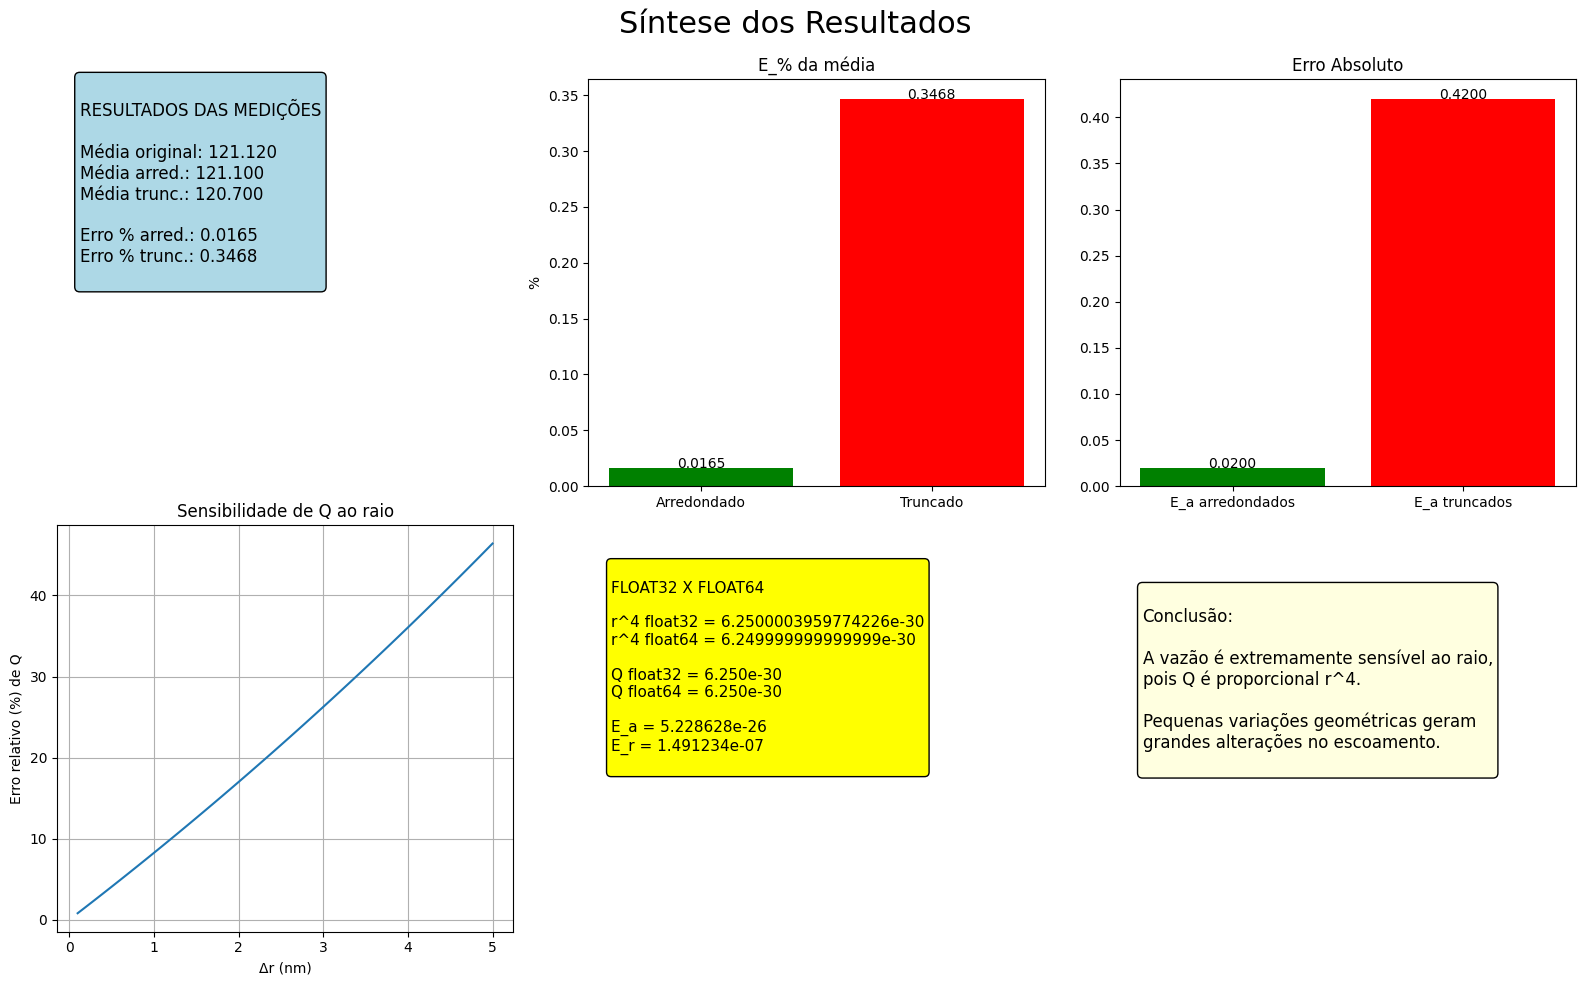

In [20]:
fig = plt.figure(figsize=(16,10))
fig.suptitle("Síntese dos Resultados", fontsize=22)

ax1= plt.subplot(2,3,1) #2 linhas, 3 colunas, 6 blocos de 1 a 6
ax1.axis("off")
#Simulando um grafico sem nada desenhado, para escrever os dados

texto = f"""
RESULTADOS DAS MEDIÇÕES

Média original: {media_o:.3f}
Média arred.: {media_r:.3f}
Média trunc.: {media_t:.3f}

Erro % arred.: {Ep_arred_media:.4f}
Erro % trunc.: {Ep_trunc_media:.4f}
"""
ax1.text(
    0.05,0.5,texto,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightblue") #criando conteiner para os textos
); #o ; evita um monte de texto de lixo aparecendo

ax2 = plt.subplot(2,3,2)
categorias = ["Arredondado", "Truncado"]
valores=[Ep_arred_media, Ep_trunc_media]

ax2.bar(categorias, valores, color=["green", "red"])
ax2.set_title("E_% da média");
ax2.set_ylabel("%");

for i, v in enumerate(valores):
    ax2.text(i, v, f"{v:.4f}", ha="center")#colocar valor em cima da barra

ax3 = plt.subplot(2,3,3)
valores = [Ea_arred_media, Ea_trunc_media]
ax3.bar(
    ["E_a arredondados", "E_a truncados"],
    valores,
    color=["green", "red"]
)
ax3.set_title("Erro Absoluto");

for i, v in enumerate(valores):
    ax3.text(i, v, f"{v:.4f}", ha="center")

#sensibilidade ao raio
ax4 = plt.subplot(2,3,4)
ax4.plot(
    delta_r_array*1e9,
    np.array(erro_rel_max)*100
)

ax4.set_title("Sensibilidade de Q ao raio")
ax4.set_xlabel("Δr (nm)")
ax4.set_ylabel("Erro relativo (%) de Q")
ax4.grid(True)

#hora de comparar os floats
r32 = np.float32(r_nominal)
r64 = np.float64(r_nominal)

r432 = r32**4
r464 = r64**4

Q32 = calcular_Q(r32)
Q64 = calcular_Q(r64)

erro_abs_float = abs(Q64 - Q32)
erro_rel_float = erro_abs_float/abs(Q64)

ax5 = plt.subplot(2,3,5)
ax5.axis("off")

texto_float= f"""
FLOAT32 X FLOAT64

r^4 float32 = {r432}
r^4 float64 = {r464}

Q float32 = {r432:.3e}
Q float64 = {r464:.3e}

E_a = {erro_abs_float:3e}
E_r = {erro_rel_float:3e}
"""

ax5.text(
    0.05, 0.4, texto_float,
    fontsize=11,
    bbox=dict(boxstyle="round",facecolor="yellow")
);

ax6 = plt.subplot(2,3,6)
ax6.axis("off")

conclusao = """
Conclusão:

A vazão é extremamente sensível ao raio,
pois Q é proporcional r^4.

Pequenas variações geométricas geram
grandes alterações no escoamento.
"""

ax6.text(
    0.05,0.4,conclusao,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightyellow")
)

plt.tight_layout()

plt.savefig(
    "sintese_resultados.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

#8 - Geração do GIF


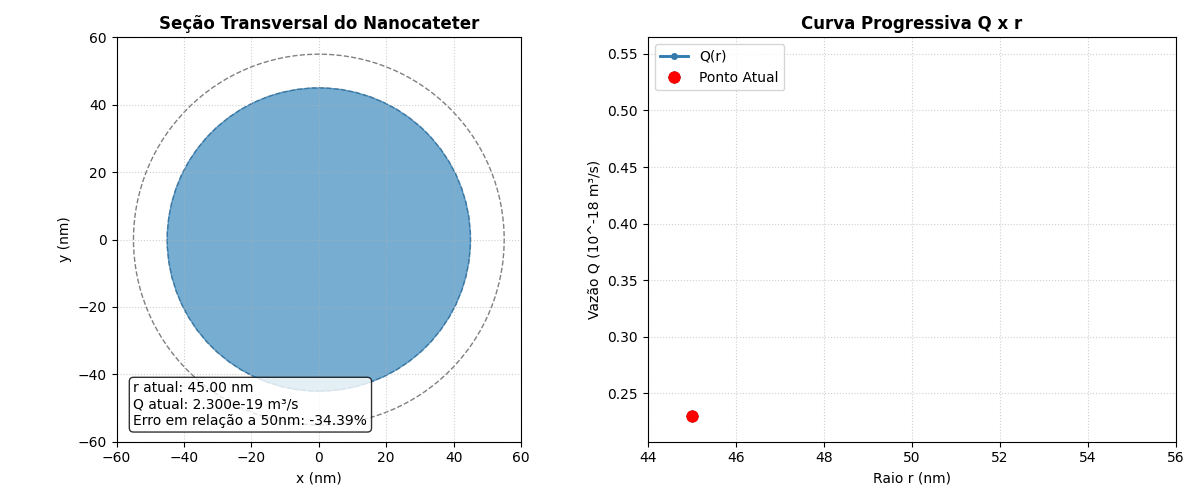

In [19]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display

#Bibliotecas para geração do GIF
num_frames = 50
r_array = np.linspace(45e-9, 55e-9, num_frames)
Q_array = calcular_Q(r_array)

Q_ref = calcular_Q(r_nominal)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

#Subplot 1: Seção Transversal do Canal
circ_max = plt.Circle((0, 0), 55, color='gray', fill=False, linestyle='--', label='Limites (45-55 nm)')
circ_min = plt.Circle((0, 0), 45, color='gray', fill=False, linestyle='--')
circ_atual = plt.Circle((0, 0), r_array[0]*1e9, color='tab:blue', alpha=0.6)

ax1.add_patch(circ_max)
ax1.add_patch(circ_min)
ax1.add_patch(circ_atual)
ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_aspect('equal')
ax1.set_title('Seção Transversal do Nanocateter', fontsize=12, fontweight='bold')
ax1.set_xlabel('x (nm)')
ax1.set_ylabel('y (nm)')
ax1.grid(True, linestyle=':', alpha=0.6)

#Texto informativo dinâmico
texto_info = ax1.text(-55, -55, '', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

#Subplot 2: Curva Q x r Progressiva
line_curva, = ax2.plot([], [], 'o-', color='tab:blue', lw=2, ms=4, label='Q(r)')
point_atual, = ax2.plot([], [], 'ro', ms=8, label='Ponto Atual')

ax2.set_xlim(44, 56)
ax2.set_ylim(min(Q_array)*1e18 * 0.9, max(Q_array)*1e18 * 1.1)
ax2.set_title('Curva Progressiva Q x r', fontsize=12, fontweight='bold')
ax2.set_xlabel('Raio r (nm)')
ax2.set_ylabel('Vazão Q (10^-18 m³/s)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()

#Atualização dos frames
def update(frame):
    r_curr = r_array[frame]
    Q_curr = Q_array[frame]
    r_nm = r_curr * 1e9

    #Erro percentual em relação a r = 50 nm
    erro_pct = ((Q_curr - Q_ref) / Q_ref) * 100

    #Atualiza Seção Transversal
    circ_atual.set_radius(r_nm)
    texto_info.set_text(
        f"r atual: {r_nm:.2f} nm\n"
        f"Q atual: {Q_curr:.3e} m³/s\n"
        f"Erro em relação a 50nm: {erro_pct:+.2f}%"
    )

    #Atualização Curva Progressiva
    r_prog = r_array[:frame+1] * 1e9
    Q_prog = Q_array[:frame+1] * 1e18

    line_curva.set_data(r_prog, Q_prog)
    point_atual.set_data([r_nm], [Q_curr * 1e18])

    return circ_atual, texto_info, line_curva, point_atual

anim = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)
plt.close(fig)  #Evita exibir a figura estática extra no notebook

#Salva o arquivo GIF no ambiente do Colab
gif_filename = 'nanocateter_animacao.gif'
anim.save(gif_filename, writer='pillow', fps=5)

display(Image(filename=gif_filename))

# Conclusão
Primeiramente, uma coisa a se notar é como **o método de arredondamento é mais preciso do que truncamento**, entretanto, o arrendodamento por inteiro especificamente é o exato contrário, "enxugando" muita informação, o que limita a precisão. Ademais, temos um problema semelhante com o método da aproximação linear (parte D), em que, com valores baixos de erro relativo, ela o acompanha e se assemelha bem, mas **conforme esses valores crescem, também aumenta a disparidade entre o valor original e o aproximado**. Também vimos a dferença entre um resultado *matematicamente preciso* e *fisicamente adequado*. Alem disso, **constata-se diferença existente entre os tipos de dados float32 e float64**, porém é muito pequena (na escala de 10⁻²⁶ no exercício 7), portanto é seguro dizer que **a escolha do tipo de dados será um fator decisivo apenas em escalas muito pequenas**. Por último, quando falamos sobre a sensibilidade de Q ao erro de r, estamos falando basicamente sobre *propagação de erro*, e o resulado obtido demonstra que conforme o erro em um valor "intermediário" cresce, o erro no resultado final cresce exponencialmente: no caso do exercicío 7, temos que um valor na escala de 10⁻⁹ é utilizado elevado à quarta potência na fórmula e conforme o erro absoluto cresce 1 unidade na escala nano, o erro relativo de Q aumenta ao passo das dezenas percentuais.
